# AP 155 Lab Exercise
---
## Exercise 4: Derivatives

_Instructions_: 
- **Report figure (See Problem 1):** Plot of mean absolute error vs. step size (spacing between points) when using the forward, backward, and central difference approach to get first derivative
- **Report discussion:** Explain the results of your figure. How do the central and non-central difference formulas arrive at such accuracies? Looking outward, when is each method of differentiation suitable/appropriate? 
  
- **Code**: Complete the codes and ensure they are functional, error-free, readable, and efficient (where needed). Include a concise markdown documentation highlighting the critical steps of your algorithm for each problem.

### Student Information
- _Full Name (Last Name, First Name)_:  Domingo, Judiele Fatima P.
- _Student No._: 2023-05167
- _Section_: THU-TX-1

### Grading Information (c/o Lab Instructor)
- [Rubrics description link](https://drive.google.com/file/d/1BMSlPot2Mc7XLu0eo4S8I8gLBsIadbCL/view?usp=sharing) (Note: percentages may still be tweaked)

| Criteria | Score | Subtotal |
| --- | --- | --- |
| Report figure | XX | 20 |
| Report discussion | XX | 20|
| Code readability | XX | 20 |
| Code efficiency | XX | 20 | 
| Code appropriateness  | XX | 20 | 
| **TOTAL** | XXX | 100 |

_Date and Time Scored (MM/DD/YYYY HH:MM AM/PM):_:_

---
## Section 1: Report

### Report figure

<img src="4derivative_approximations.png" alt="First Derivative Approximations" width=45%> 

**FIGURE 1** : First derivative approximations vs. calculated derivative
The first derivative of the function $f(x)=2 + 5x\sin\left(x + \frac{\pi}{4}\right)$ using the forward, backward, and central difference method was compared against the manually calculated derivative: $\frac{df(x)}{dx} =  5\sin(x+\frac{\pi}{4} +5x\cos(x+\frac{\pi}{4})$. The derivatives are plotted over the domain $x \in [0, 12.5]$. The plotted functions coinside with one another. 

<img src="4MAE.png" alt="Mean Absolute Error vs. Step size" width=45%>

**FIGURE 2**: Mean absolute error vs. step size
The mean absolute error of the forward, backward and central difference methods are plotted against the step size. The MAE is plotted on a logarithmic scale. The plotted functions are linear with the central difference method showing the least error. 

### Report discussion

Figure 2 shows the relationship between the MAE and the step size, as the step size increases the error also increases. The larger step size causes truncation errors because 2 far apart data points were used to calculate the derivative.

The forward and backward difference method yielded identical slopes. Both methods make use of one chosen x point and information from one side of x. The difference being, forward difference uses 1 data point to the right of x and the backward difference method uses 1 data point to the left of x. Thus showing the same error behavior in fig. 2. Since both methods ignore information from the opposite side, they create more truncation errors.

The central difference method showed the least error in fig.2. This method uses information from both sides of x thus resulting in less errors. In addition, from the equation given in section 3, the truncation error is now proportional to $h^2$ as compared to the forward and backward methods which are proportional to h. Since the central difference method is second-order accurate, a smaller step size more rapidly decreases the error.

The method used will depend on the available data. If information on both sides of x are given, especially for larger data sets, the central difference method is ideal. For smaller data sets with information only on one side however, forward and backward difference methods are more appropriate. Forward difference is more suited for the beginning of the interval since the function,*forward_approximation()*, fails to approximate the derivative of the last data point. Conversely, backward difference is more suited for the end of an interval since the function, *backward_approximation()* fails to approximate the derivative of the first data point. 

### Other comments
- N/A


---
## Section 2: Code

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math

### Problem 1:

Consider the function:
$$ f(x) = 2 + 5x\sin\left(x + \frac{\pi}{4}\right)$$

Say you start with 257 points from 0 to $4\pi$ 

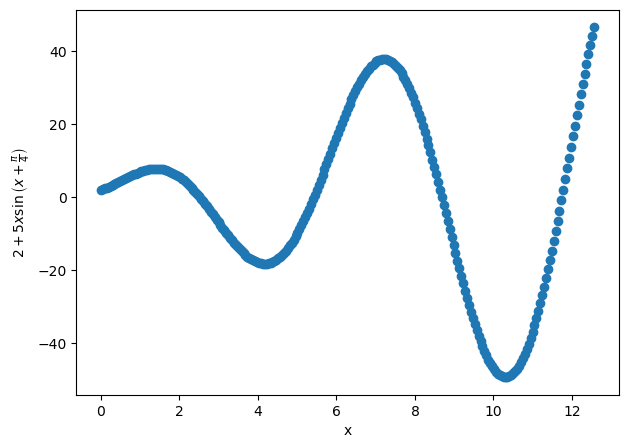

In [2]:
f_0 = lambda x: 2 + 5*x*np.sin(1*x+np.pi/4)
num = 257
x = np.linspace(0, 4*np.pi, num)
fig, ax = plt.subplots(figsize = (7,5))
ax.scatter(x, f_0(x))
ax.set_ylabel(r"$2 + 5x\sin\left(x + \frac{\pi}{4}\right)$")
ax.set_xlabel("x")
fig.show()
fig.savefig('f_x.png')

- Create a function that gets the first derivative approximation using the forward, backward, and central difference formulas. (Bonus, not required): Make the function flexible to non-evenly spaced data
- To give yourself a visualization, plot (in a single axis):
  - the three derivative approximations
  - the analytically derived function

- Get the mean absolute error of each of the approximations compared to the analytically derived function
- Repeat the above step for increasing number of points (decreasing spacing) - instead of 256 points, take 512/1024/128/64 points, etc.

- (For the report) Make a plot of the mean absolute error vs the spacing between points. In this plot, there should be three curves: One for the forward, one for the backward, and one for the central difference approximation

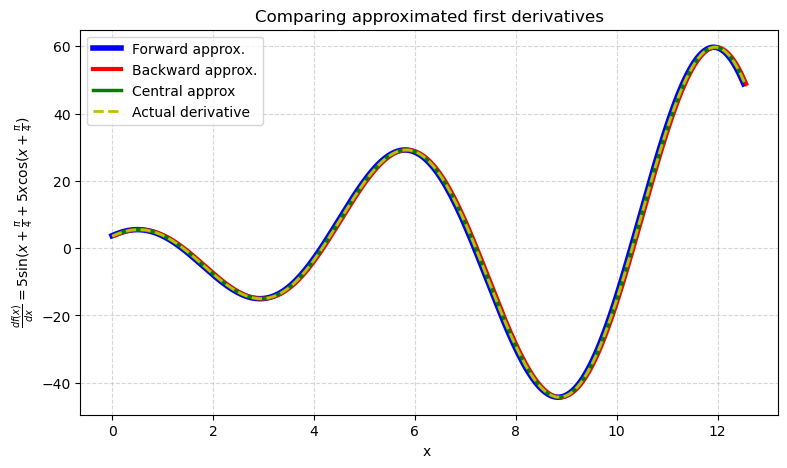

In [3]:
"""
 - 
 - save f(x_i) and f(x_i+1) as 2 arrays
 - get the difference of the arrays 
 - over h, h = x1-x
"""
f = 2 + 5*x*np.sin(1*x +np.pi/4) #original function
f_prime = 5*np.sin(1*x +np.pi/4) + 5*x*np.cos(1*x + np.pi/4) #Computed derivative

def forward_approximation (F,X):
    f_xi = F [:-1]
    f_xi_plus_1 = F [1:]
    difference = f_xi_plus_1-f_xi
    h =  X[1:] - X[:-1]
    return difference/h
    
def backward_approximation (F,X):
    f_xi = F [1:]
    f_xi_minus_1 = F[:-1]
    difference = f_xi_minus_1-f_xi
    h = X[:-1] - X[1:]
    return difference/h

def central_approximation (F,X):
    f_x_plus_1 = F [2:]
    f_x_minus_1 = F[:-2]
    difference = f_x_plus_1-f_x_minus_1
    two_h = X[2:] - X[:-2]
    return difference/two_h

#calling functions
y_forward = forward_approximation (f,x)
y_backward = backward_approximation (f,x)
y_central = central_approximation (f,x)

plt.figure(figsize=(9, 5))
plt.xlabel('x ')
plt.ylabel(r"$\frac{df(x)}{dx} =  5\sin(x+\frac{\pi}{4} +5x\cos(x+\frac{\pi}{4})$")
plt.title('Comparing approximated first derivatives')
plt.plot(x[:-1], y_forward, 'b-', label='Forward approx.', linewidth=4)
plt.plot(x[1:], y_backward, 'r-', label='Backward approx.', linewidth=3)
plt.plot(x[1:-1], y_central, 'g-', label='Central approx', linewidth=2.5)
plt.plot(x, f_prime, 'y--', label='Actual derivative', linewidth=2)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()
plt.show()

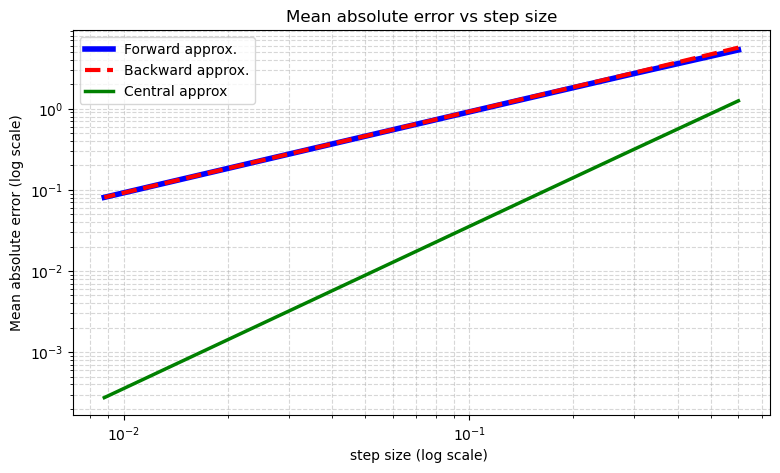

In [4]:
#gets the mean absolute error at one step size
def mean_absolute_error (f,f_actual):
    error = np.abs(f - f_actual)
    return sum(error) / len(error)

#creating arrays for step size and MAE of diff methods
step_size= []
MAE_forward = []
MAE_backward = []
MAE_central = []

#calculates derivative approximation and MAE of each method for increasng spacing
for N in [16, 32, 64, 128, 256, 512, 1024]:  
    num=N
    x = np.linspace(1, 10, num)
    f = 2 + 5*x*np.sin(1*x +np.pi/4) #original function
    f_prime = 5*np.sin(1*x +np.pi/4) + 5*x*np.cos(1*x + np.pi/4) #Computed derivative

    y_forward = forward_approximation(f,x) #calculates approx derivatives per spacing
    y_backward = backward_approximation(f,x)
    y_central = central_approximation(f,x)

    step_size.append(x[1]-x[0]) #saves step size into array

    #calculates MAE for each method and saves into array
    MAE_forward.append(mean_absolute_error(y_forward,f_prime[:-1]))
    MAE_backward.append(mean_absolute_error(y_backward,f_prime[1:]))
    MAE_central.append(mean_absolute_error(y_central,f_prime[1:-1]))

#plotting using step-size as x-axis and MAE as y-axis
plt.figure(figsize=(9, 5))
plt.xscale('log')
plt.yscale('log')
plt.xlabel('step size (log scale) ')
plt.ylabel("Mean absolute error (log scale)")
plt.title('Mean absolute error vs step size')
plt.plot(step_size, MAE_forward, 'b-', label='Forward approx.', linewidth=4)
plt.plot(step_size, MAE_backward, 'r--', label='Backward approx.', linewidth=3)
plt.plot(step_size, MAE_central, 'g-', label='Central approx', linewidth=2.5)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()
plt.show()


#### Problem 1 code summary

The first cell defines the needed functions to approximate the derivative of f(x) using forward, backward, and central differences. A function to get the mean absolute error of one data point was also created. A for loop was created to calculate the derivatives using all methods then MAE at varying spacing was calculated and plotted against step size in log scale. 

---

## Section 3 (Notes)

### Non-central difference formulas (First Derivative)

* Forward 
$$
f'(x_i) = \frac{f(x_{i+1}) - f(x_{x})}{h} + O(h)
$$

* Backward
$$
f'(x_i) = \frac{f(x_{i}) - f(x_{i-1})}{h} + O(h)
$$



### Central-difference formulas

* First Derivative
$$
f'(x_i) = \frac{f(x_{i+1}) - f(x_{i-1})}{2h} + O(h^2)
$$

* Second Derivative
$$
f''(x_i) = \frac{f(x_{i+1}) - 2f(x_{i}) + f(x_{i-1})}{h^2} + O(h^2)
$$

Note: to avoid confusion, think: $x_i$ is `x[i]`, and $h$ is the gap between `x[i+1]` and `x[i]`.


In [5]:
## Useful tips. Not required to solve the problems below!

# Suppose you have a Numpy array
x = np.linspace(1, 10, 10)
print(x)

# I can move all values to the left/right using roll
x_roll = np.roll(x, 1) # change 1 to -1, what happens? 
x_roll2 = np.roll(x, -1)
print(x_roll)

# then I could exploit array operations to get their difference
x_diff = (x_roll - x)[1:]
print(x_diff)
# Be careful with the boundaries!

x_diff2 = (x_roll2 - x_roll)[:]
print(x_diff2)

[ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10.]
[10.  1.  2.  3.  4.  5.  6.  7.  8.  9.]
[-1. -1. -1. -1. -1. -1. -1. -1. -1.]
[-8.  2.  2.  2.  2.  2.  2.  2.  2. -8.]
